In [1]:
# !pip install catboost
# !pip install optuna

# Respiratory Diagnosis Modeling Pipeline

This notebook is organized into parts: environment setup, data loading, feature engineering, split strategy, model training, and evaluation.

Goal: build a robust multi-class classifier for respiratory diagnosis while keeping the workflow reproducible and interpretable.

In [2]:
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import torch
import torch.nn as nn
import torch.optim as optim
import xgboost as xgb
import lightgbm as lgb
from catboost import CatBoostClassifier
from scipy.spatial.distance import cdist
from sklearn.base import clone
from sklearn.calibration import CalibratedClassifierCV
from sklearn.ensemble import ExtraTreesClassifier, RandomForestClassifier, StackingClassifier
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report, confusion_matrix, f1_score, fbeta_score
from sklearn.model_selection import StratifiedKFold, train_test_split
from sklearn.naive_bayes import GaussianNB
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.svm import SVC

## Part 1. Environment and Dependencies

Install optional packages and prepare paths for loading the dataset in Colab/local runtime.

In [3]:
CONFIG = {
    'random_seed': 42,
    'test_size': 0.2,
    'cv_folds': 5,
    'cvae_epochs': 1600,
    'threshold_grid_low': 0.01,
    'threshold_grid_high': 0.7,
    'threshold_grid_steps': 70,
    'max_infection_threshold': 0.18,
    'use_cvae_augmentation': True,
    'threshold_val_size': 0.2,
}

np.random.seed(CONFIG['random_seed'])
torch.manual_seed(CONFIG['random_seed'])

print('Config loaded:', CONFIG)

Config loaded: {'random_seed': 42, 'test_size': 0.2, 'cv_folds': 5, 'cvae_epochs': 1600, 'threshold_grid_low': 0.01, 'threshold_grid_high': 0.7, 'threshold_grid_steps': 70, 'max_infection_threshold': 0.18, 'use_cvae_augmentation': True, 'threshold_val_size': 0.2}


In [4]:
REPO_PATH = Path('/content/course_paper')
DATA_REL_PATH = 'colab/data/enlarged_dataset.csv'

if REPO_PATH.exists():
    print('Repository exists, updating...')
    !git -C {REPO_PATH} fetch origin main --depth 1
    !git -C {REPO_PATH} reset --hard origin/main
else:
    print('Cloning repository...')
    !git clone --depth 1 --filter=blob:none --sparse https://github.com/incRED1bl/course_paper.git {REPO_PATH}

!git -C {REPO_PATH} sparse-checkout set {DATA_REL_PATH}

sys.path.insert(0, str(REPO_PATH))

src = REPO_PATH / DATA_REL_PATH
dst_dir = Path('/content/data')
dst_dir.mkdir(parents=True, exist_ok=True)
dst = dst_dir / 'enlarged_dataset.csv'

if src.exists():
    !cp {src} {dst}
    print(f'Dataset copied to {dst}')
else:
    raise FileNotFoundError(f'Dataset not found at {src}')

Repository exists, updating...
remote: Total 0 (delta 0), reused 0 (delta 0), pack-reused 0 (from 0)
From https://github.com/incRED1bl/course_paper
 * branch            main       -> FETCH_HEAD
HEAD is now at 07e5c90 85 on test
Dataset copied to /content/data/enlarged_dataset.csv


## Part 2. Data Loading and Basic Cleaning

Load feature table, remove metadata columns, and keep only labeled diagnoses.

In [5]:
df = pd.read_csv('/content/course_paper/colab/data/enlarged_dataset.csv')
df.head()

,file_id,filename,relative_path,dataset,patient_id,low_freq_energy,spectral_centroid,entropy,complexity,diagnosis,zcr_variance,rmse_coeff_var,spectral_flatness,hjorth_mobility,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var
0,respiratory_sound_database::Respiratory_Sound_...,102_1b1_Ar_sc_Meditron.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,2,0.697796,1253.170052,0.898144,0.087052,Healthy,2.836290e-06,0.491985,1.066887e-11,0.004815,411.830967,346.868516,95.075281,502.025984,62.562664,265.129376
1,respiratory_sound_database::Respiratory_Sound_...,103_2b2_Ar_mc_LittC2SE.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,3,0.658031,2190.655897,0.868986,0.110194,Asthma,7.153194e-07,0.548712,1.070353e-10,0.002059,1682.543709,203.158471,59.045874,163.056532,46.305899,50.537224
2,respiratory_sound_database::Respiratory_Sound_...,104_1b1_Ar_sc_Litt3200.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,4,0.799876,198.766348,0.701699,0.210539,COPD,2.904132e-04,0.552153,3.401299e-09,0.242970,711.369012,5449.418212,187.456382,794.549863,16.394298,1027.223633
3,respiratory_sound_database::Respiratory_Sound_...,105_1b1_Tc_sc_Meditron.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,5,0.396047,2338.788742,0.933559,0.059629,URTI,5.539475e-04,0.530288,2.041829e-07,0.113771,1730.755780,2982.187645,153.423952,2439.313522,71.694684,120.153273
4,respiratory_sound_database::Respiratory_Sound_...,106_2b1_Pl_mc_LittC2SE.wav,Respiratory_Sound_Database/Respiratory_Sound_D...,respiratory_sound_database,6,0.814369,1303.551393,0.921622,0.069483,COPD,3.560188e-05,0.784495,4.228126e-09,0.018662,1617.788718,138.173383,118.308106,214.539517,38.049638,173.949463


In [6]:
display(df['diagnosis'].value_counts())

,count
diagnosis,
COPD,465
Pneumonia,291
Asthma,289
Healthy,159
Bronchial,104
URTI,13
Bronchiectasis,7
Bronchiolitis,6
LRTI,2


In [7]:
meta_cols = ['filename', 'patient_id', 'file_id', 'relative_path', 'dataset']
df = df.drop(columns=meta_cols, errors='ignore')

if 'diagnosis' not in df.columns:
    raise ValueError("Expected 'diagnosis' column in dataset")

df = df[df['diagnosis'].notna()]
df = df[df['diagnosis'] != 'Unknown']

infection_labels = {'Pneumonia', 'URTI', 'LRTI', 'Bronchiolitis'}
copd_labels = {'COPD', 'Asthma', 'Bronchiectasis', 'Bronchial'}

def map_to_3class(label):
    if label == 'Healthy':
        return 'Healthy'
    if label in infection_labels:
        return 'Infection'
    if label in copd_labels:
        return 'COPD'
    return np.nan

df['diagnosis_3class'] = df['diagnosis'].apply(map_to_3class)
dropped_unmapped = int(df['diagnosis_3class'].isna().sum())
df = df.dropna(subset=['diagnosis_3class']).copy()

print(f'Dropped unmapped rows: {dropped_unmapped}')
print('3-class distribution:')
display(df['diagnosis_3class'].value_counts())
df.head()

Dropped unmapped rows: 0
3-class distribution:


,count
diagnosis_3class,
COPD,865
Infection,312
Healthy,159


,low_freq_energy,spectral_centroid,entropy,complexity,diagnosis,zcr_variance,rmse_coeff_var,spectral_flatness,hjorth_mobility,mfcc_1_mean,mfcc_1_var,mfcc_2_mean,mfcc_2_var,mfcc_3_mean,mfcc_3_var,diagnosis_3class
0,0.697796,1253.170052,0.898144,0.087052,Healthy,2.836290e-06,0.491985,1.066887e-11,0.004815,411.830967,346.868516,95.075281,502.025984,62.562664,265.129376,Healthy
1,0.658031,2190.655897,0.868986,0.110194,Asthma,7.153194e-07,0.548712,1.070353e-10,0.002059,1682.543709,203.158471,59.045874,163.056532,46.305899,50.537224,COPD
2,0.799876,198.766348,0.701699,0.210539,COPD,2.904132e-04,0.552153,3.401299e-09,0.242970,711.369012,5449.418212,187.456382,794.549863,16.394298,1027.223633,COPD
3,0.396047,2338.788742,0.933559,0.059629,URTI,5.539475e-04,0.530288,2.041829e-07,0.113771,1730.755780,2982.187645,153.423952,2439.313522,71.694684,120.153273,Infection
4,0.814369,1303.551393,0.921622,0.069483,COPD,3.560188e-05,0.784495,4.228126e-09,0.018662,1617.788718,138.173383,118.308106,214.539517,38.049638,173.949463,COPD


## Part 3. Feature Engineering

Create relational acoustic features and class-distance features to enrich representation before model training.

In [8]:
def engineer_relational_features(df):
    new_df = df.copy()
    eps = 1e-6

    def get_numeric(col_name):
        if col_name in new_df.columns:
            return pd.to_numeric(new_df[col_name], errors='coerce').fillna(0.0)
        return None

    low = get_numeric('low_freq_energy')
    complexity = get_numeric('complexity')
    centroid = get_numeric('spectral_centroid')
    entropy = get_numeric('entropy')


    flatness = get_numeric('spectral_flatness')
    mobility = get_numeric('hjorth_mobility')


    new_df['entropy_complexity_interaction'] = entropy * complexity

    if flatness is not None:
        new_df['centroid_flatness_ratio'] = centroid / (flatness + eps)

    if mobility is not None:
        new_df['mobility_complexity_ratio'] = mobility / (complexity + eps)


    peak = get_numeric('peak_frequency')
    if peak is not None:
        new_df['centroid_peak_diff'] = centroid - peak
        new_df['centroid_peak_ratio'] = centroid / (peak + eps)

    new_df = new_df.replace([np.inf, -np.inf], np.nan).fillna(0)
    return new_df

In [9]:
def add_class_distance_features(train_df, test_df, feature_cols, target_col='diagnosis'):
    usable_cols = []
    for col in feature_cols:
        if col in train_df.columns and col in test_df.columns:
            if pd.api.types.is_numeric_dtype(train_df[col]):
                usable_cols.append(col)

    if not usable_cols:
        raise ValueError('No numeric feature columns available for class-distance features.')

    dist_scaler = StandardScaler()
    train_scaled = dist_scaler.fit_transform(train_df[usable_cols])
    test_scaled = dist_scaler.transform(test_df[usable_cols])

    centroids = train_df.groupby(target_col)[usable_cols].mean()
    centroids_scaled = dist_scaler.transform(centroids)

    dist_train = cdist(train_scaled, centroids_scaled, metric='euclidean')
    dist_test = cdist(test_scaled, centroids_scaled, metric='euclidean')

    dist_cols = [f'dist_to_{cls}' for cls in centroids.index]
    df_dist_train = pd.DataFrame(dist_train, columns=dist_cols, index=train_df.index)
    df_dist_test = pd.DataFrame(dist_test, columns=dist_cols, index=test_df.index)

    return pd.concat([train_df, df_dist_train], axis=1), pd.concat([test_df, df_dist_test], axis=1)

In [10]:
class CVAE(nn.Module):
    def __init__(self, feature_dim, class_dim, latent_dim=4):
        super(CVAE, self).__init__()
        self.encoder = nn.Sequential(
            nn.Linear(feature_dim + class_dim, 32),
            nn.ReLU(),
            nn.Linear(32, latent_dim * 2)
        )
        self.decoder = nn.Sequential(
            nn.Linear(latent_dim + class_dim, 32),
            nn.ReLU(),
            nn.Linear(32, feature_dim)
        )

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x, c):
        inputs = torch.cat([x, c], dim=1)
        h = self.encoder(inputs)
        mu, logvar = torch.chunk(h, 2, dim=1)
        z = self.reparameterize(mu, logvar)
        z_cond = torch.cat([z, c], dim=1)
        return self.decoder(z_cond), mu, logvar

In [11]:
def train_cvae_module(X_train, y_enc, epochs=250):
    feature_dim = X_train.shape[1]
    class_dim = len(np.unique(y_enc))

    model = CVAE(feature_dim, class_dim)
    optimizer = optim.Adam(model.parameters(), lr=1e-3)

    x_tensor = torch.FloatTensor(X_train.values)
    c_tensor = torch.FloatTensor(np.eye(class_dim)[y_enc])

    model.train()
    for epoch in range(epochs):
        recon_x, mu, logvar = model(x_tensor, c_tensor)
        recon_loss = nn.functional.mse_loss(recon_x, x_tensor, reduction='sum')
        kld_loss = -0.5 * torch.sum(1 + logvar - mu.pow(2) - logvar.exp())
        loss = recon_loss + kld_loss

        optimizer.zero_grad()
        loss.backward()
        optimizer.step()
    return model



In [12]:
def generate_borderline_samples(model, class_idx, num_samples, class_dim, feature_names, sigma=1.5):
    model.eval()
    with torch.no_grad():
        c = torch.zeros(num_samples, class_dim)
        c[:, class_idx] = 1
        z = torch.randn(num_samples, 4) * sigma
        z_cond = torch.cat([z, c], dim=1)
        samples = model.decoder(z_cond).numpy()
    return pd.DataFrame(samples, columns=feature_names)

## Part 4. Train/Test Split Strategy

Use stratified 80/20 split on diagnosis labels, then derive distance-based features from train centroids and apply them to test set.

This prevents leakage: class centroids are fitted on train data only.

In [13]:
df_eng = engineer_relational_features(df)

X_train_raw, X_test_raw, y_train_raw, y_test_raw = train_test_split(
    df_eng,
    df_eng['diagnosis_3class'],
    test_size=CONFIG['test_size'],
    stratify=df_eng['diagnosis_3class'],
    random_state=CONFIG['random_seed'],
)

# Dynamically identify numeric columns to avoid hardcoding missing ones
feature_block = X_train_raw.drop(columns=['diagnosis', 'diagnosis_3class'], errors='ignore')
numeric_cols = feature_block.select_dtypes(include=[np.number]).columns.tolist()

X_train_raw = X_train_raw[numeric_cols + ['diagnosis_3class']].copy()
X_test_raw = X_test_raw[numeric_cols + ['diagnosis_3class']].copy()

X_train_dist, X_test_dist = add_class_distance_features(
    X_train_raw,
    X_test_raw,
    numeric_cols,
    target_col='diagnosis_3class',
)

le = LabelEncoder()
y_train_enc = le.fit_transform(X_train_dist['diagnosis_3class'])
y_test_enc = le.transform(X_test_dist['diagnosis_3class'])

X_train_final = X_train_dist.drop(columns=['diagnosis_3class'])
X_test_final = X_test_dist.drop(columns=['diagnosis_3class'])

X_train_to_fit = X_train_final.copy()
y_train_to_fit = y_train_enc.copy()

print(f'Cleaned Pipeline: {len(numeric_cols)} base features, {X_train_to_fit.shape[1]} total features.')

Cleaned Pipeline: 17 base features, 20 total features.


In [14]:
assert len(X_train_to_fit) == len(y_train_to_fit), 'Train X/y length mismatch.'
assert len(X_test_final) == len(y_test_enc), 'Test X/y length mismatch.'
assert 'diagnosis' not in X_train_to_fit.columns, 'Target leakage: diagnosis column found in training features.'

print('Sanity check passed: split outputs are shape-consistent.')
print('Train shape:', X_train_to_fit.shape, '| Test shape:', X_test_final.shape)
print('Encoded train class counts:\n', pd.Series(y_train_to_fit).value_counts().sort_index())

Sanity check passed: split outputs are shape-consistent.
Train shape: (1068, 20) | Test shape: (268, 20)
Encoded train class counts:
 0    692
1    127
2    249
Name: count, dtype: int64


## Part 5. Optional CVAE Augmentation

Train CVAE on tabular features. Synthetic sample generation is optional and currently left commented to keep baseline reproducible.

In [15]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.utils import resample
import pandas as pd
import numpy as np

print('Preparing data for training...')

if CONFIG.get('use_cvae_augmentation', False):
    print('CVAE augmentation is enabled.')

    cvae_imputer = SimpleImputer(strategy='median')
    cvae_scaler = StandardScaler()

    X_train_clean = cvae_imputer.fit_transform(X_train_final)
    X_train_scaled_cvae = cvae_scaler.fit_transform(X_train_clean)
    X_train_scaled_df = pd.DataFrame(X_train_scaled_cvae, columns=X_train_final.columns)

    print('Balancing classes before CVAE training...')
    cvae_train_df = X_train_scaled_df.copy()
    cvae_train_df['target'] = y_train_enc

    max_size = cvae_train_df['target'].value_counts().max()
    balanced_classes = []
    for cls_idx in cvae_train_df['target'].unique():
        cls_data = cvae_train_df[cvae_train_df['target'] == cls_idx]
        cls_upsampled = resample(cls_data, replace=True, n_samples=max_size, random_state=42)
        balanced_classes.append(cls_upsampled)

    cvae_train_balanced = pd.concat(balanced_classes).reset_index(drop=True)
    X_cvae_fit = cvae_train_balanced.drop(columns=['target'])
    y_cvae_fit = cvae_train_balanced['target'].values

    print(f"Training CVAE (epochs: {CONFIG['cvae_epochs']})...")
    cvae_model_scaled = train_cvae_module(
        X_cvae_fit,
        y_cvae_fit,
        epochs=CONFIG['cvae_epochs'],
    )

    rare_classes = ['Infection', 'Healthy']
    target_count = 300
    synthetic_list = []

    print('Generating synthetic samples...')
    for cls_name in rare_classes:
        if cls_name in le.classes_:
            idx = list(le.classes_).index(cls_name)
            gen_scaled = generate_borderline_samples(
                cvae_model_scaled, idx, target_count, len(le.classes_), X_train_final.columns, sigma=1.8
            )
            gen_raw = cvae_scaler.inverse_transform(gen_scaled)
            gen_df = pd.DataFrame(gen_raw, columns=X_train_final.columns)
            gen_df['target'] = idx
            gen_df['is_synthetic'] = 1
            synthetic_list.append(gen_df)

    if synthetic_list:
        df_synthetic = pd.concat(synthetic_list, axis=0).reset_index(drop=True)
    else:
        df_synthetic = pd.DataFrame(columns=list(X_train_final.columns) + ['target', 'is_synthetic'])

    train_full = pd.DataFrame(X_train_clean, columns=X_train_final.columns)
    train_full['target'] = y_train_enc
    train_full['is_synthetic'] = 0

    df_augmented_final = pd.concat([train_full, df_synthetic], axis=0).reset_index(drop=True)
    X_train_to_fit = df_augmented_final.drop(columns=['target', 'is_synthetic'])
    y_train_to_fit = df_augmented_final['target'].values

    print(f'Original samples: {len(train_full)}')
    print(f'Synthetic samples: {len(df_synthetic)}')
    print(f'Total samples for training: {len(X_train_to_fit)}')
else:
    print('CVAE augmentation disabled. Using original training split only.')
    train_full = pd.DataFrame(X_train_final.copy())
    train_full['target'] = y_train_enc
    train_full['is_synthetic'] = 0
    df_synthetic = pd.DataFrame(columns=list(X_train_final.columns) + ['target', 'is_synthetic'])
    X_train_to_fit = X_train_final.copy()
    y_train_to_fit = y_train_enc.copy()
    print(f'Total samples for training: {len(X_train_to_fit)}')


Preparing data for training...
CVAE augmentation is enabled.
Balancing classes before CVAE training...
Training CVAE (epochs: 1600)...
Generating synthetic samples...
Original samples: 1068
Synthetic samples: 600
Total samples for training: 1668


Augmentation quality checks:


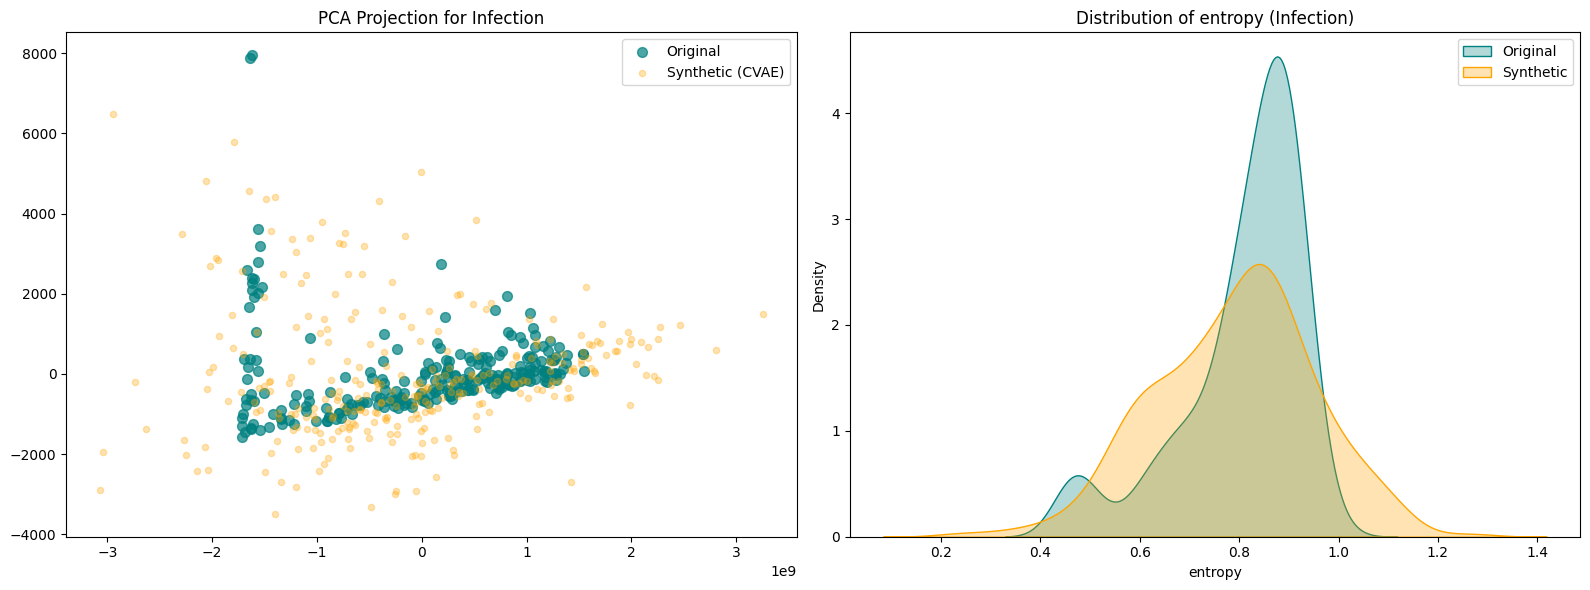

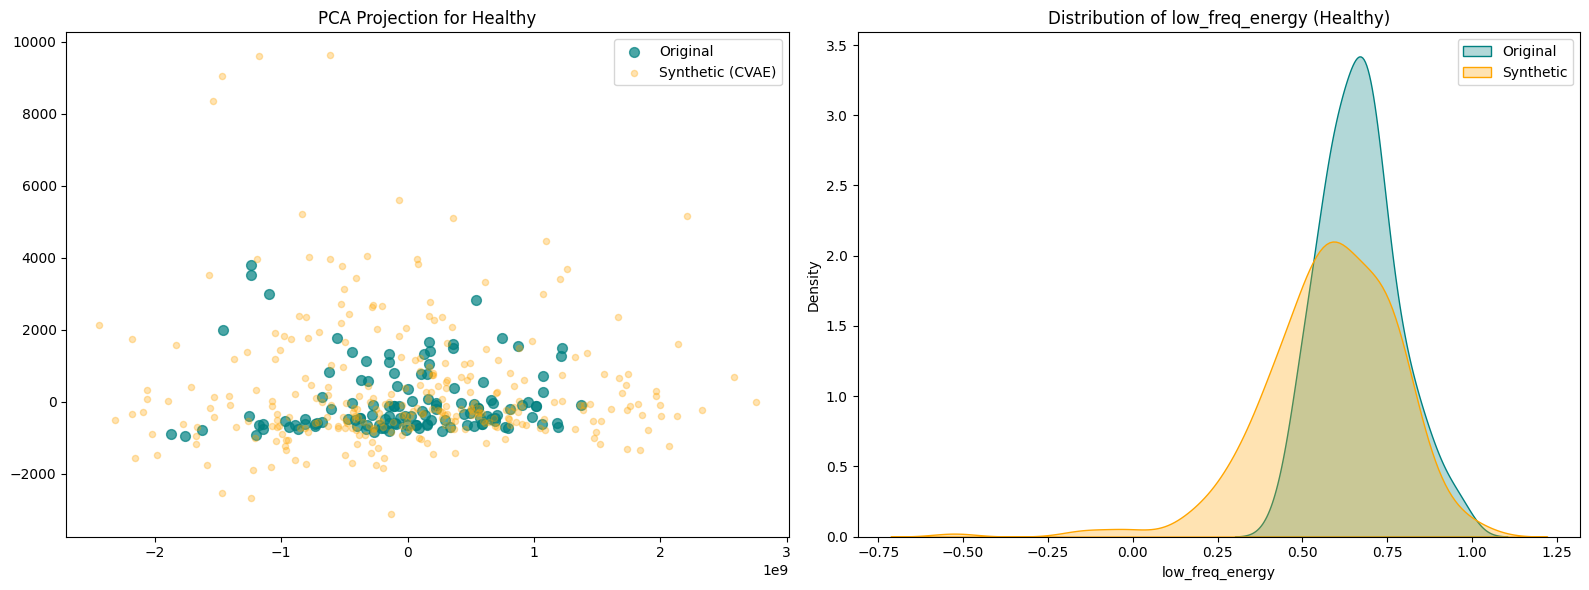

In [16]:
from sklearn.decomposition import PCA

def plot_augmentation_quality(original_df, synthetic_df, target_class_name, le, feature_to_plot='spectral_centroid'):
    if target_class_name not in le.classes_:
        print(f'Skip plot: class {target_class_name} is not present in current dataset.')
        return

    idx = list(le.classes_).index(target_class_name)
    orig_cls = original_df[original_df['target'] == idx].drop(columns=['target', 'is_synthetic'])
    synth_cls = synthetic_df[synthetic_df['target'] == idx].drop(columns=['target', 'is_synthetic'])

    if orig_cls.empty or synth_cls.empty:
        print(f'Skip plot: not enough data for class {target_class_name}.')
        return

    if feature_to_plot not in orig_cls.columns:
        print(f'Skip density plot: feature {feature_to_plot} is absent.')
        return

    fig, axes = plt.subplots(1, 2, figsize=(16, 6))

    pca = PCA(n_components=2)
    pca.fit(orig_cls)

    orig_pca = pca.transform(orig_cls)
    synth_pca = pca.transform(synth_cls)

    axes[0].scatter(orig_pca[:, 0], orig_pca[:, 1], alpha=0.7, label='Original', color='teal', s=50)
    axes[0].scatter(synth_pca[:, 0], synth_pca[:, 1], alpha=0.3, label='Synthetic (CVAE)', color='orange', s=20)
    axes[0].set_title(f'PCA Projection for {target_class_name}')
    axes[0].legend()

    sns.kdeplot(orig_cls[feature_to_plot], ax=axes[1], label='Original', color='teal', fill=True, alpha=0.3)
    sns.kdeplot(synth_cls[feature_to_plot], ax=axes[1], label='Synthetic', color='orange', fill=True, alpha=0.3)
    axes[1].set_title(f'Distribution of {feature_to_plot} ({target_class_name})')
    axes[1].legend()

    plt.tight_layout()
    plt.show()

print('Augmentation quality checks:')
plot_augmentation_quality(train_full, df_synthetic, 'Infection', le, feature_to_plot='entropy')
plot_augmentation_quality(train_full, df_synthetic, 'Healthy', le, feature_to_plot='low_freq_energy')

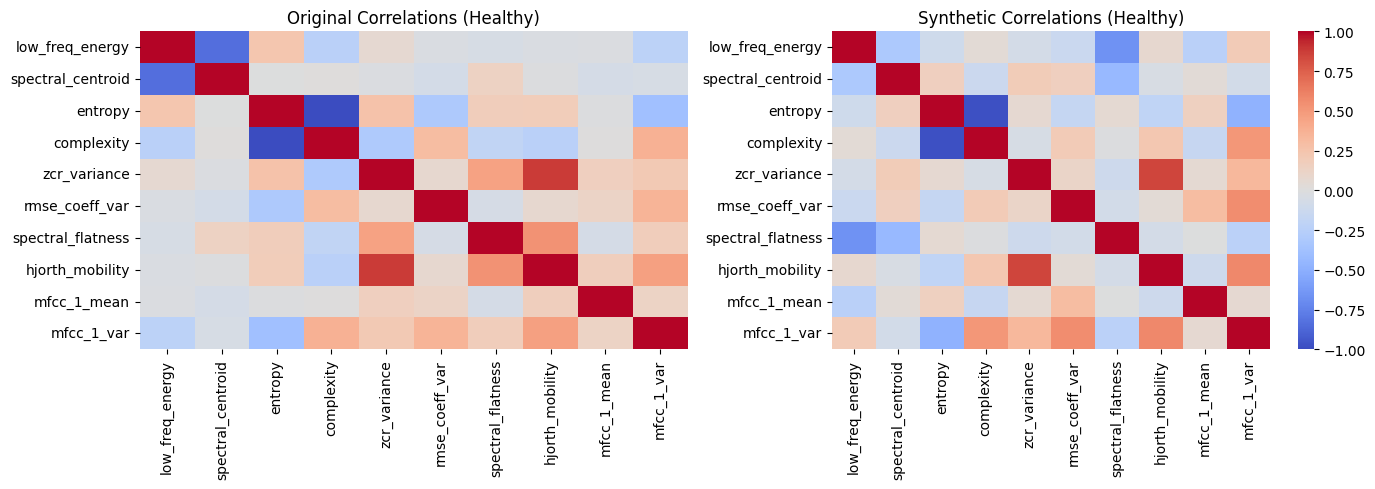

In [17]:
def plot_correlation_diff(original_df, synthetic_df, target_class_name, le):
    if target_class_name not in le.classes_:
        print(f'Skip correlation plot: class {target_class_name} is not present.')
        return

    idx = list(le.classes_).index(target_class_name)
    orig_cls = original_df[original_df['target'] == idx].drop(columns=['target', 'is_synthetic'])
    synth_cls = synthetic_df[synthetic_df['target'] == idx].drop(columns=['target', 'is_synthetic'])

    if orig_cls.empty or synth_cls.empty:
        print(f'Skip correlation plot: insufficient data for class {target_class_name}.')
        return

    cols = orig_cls.columns[:10]

    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    sns.heatmap(orig_cls[cols].corr(), cmap='coolwarm', vmin=-1, vmax=1, ax=axes[0], cbar=False)
    axes[0].set_title(f'Original Correlations ({target_class_name})')

    sns.heatmap(synth_cls[cols].corr(), cmap='coolwarm', vmin=-1, vmax=1, ax=axes[1])
    axes[1].set_title(f'Synthetic Correlations ({target_class_name})')

    plt.tight_layout()
    plt.show()

plot_correlation_diff(train_full, df_synthetic, 'Healthy', le)

In [18]:
def macro_sensitive_predict(probs, labels_list, threshold_sick=0.12):
    name_to_idx = {name: i for i, name in enumerate(labels_list)}

    infection_cluster = ['Infection']
    obstructive_cluster = ['COPD']

    inf_indices = [name_to_idx[n] for n in infection_cluster if n in name_to_idx]
    obs_indices = [name_to_idx[n] for n in obstructive_cluster if n in name_to_idx]

    final_preds = np.argmax(probs, axis=1)

    for i in range(len(probs)):
        max_inf_prob = np.max(probs[i][inf_indices]) if inf_indices else 0
        max_obs_prob = np.max(probs[i][obs_indices]) if obs_indices else 0

        if max_inf_prob > threshold_sick:
            final_preds[i] = inf_indices[np.argmax(probs[i][inf_indices])]
        elif max_obs_prob > threshold_sick:
            final_preds[i] = obs_indices[np.argmax(probs[i][obs_indices])]

    return final_preds

## Part 6. Preprocessing and Label Construction

Impute missing values, scale features, and build hierarchical binary targets used by specialist expert models.

In [19]:
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.feature_selection import SelectFromModel
from sklearn.ensemble import RandomForestClassifier

# 1. Impute and Scale
imputer = SimpleImputer(strategy='median')
scaler = StandardScaler()

X_train_imputed = imputer.fit_transform(X_train_to_fit)
X_test_imputed = imputer.transform(X_test_final)

X_train_scaled_full = pd.DataFrame(scaler.fit_transform(X_train_imputed), columns=X_train_to_fit.columns)
X_test_scaled_full = pd.DataFrame(scaler.transform(X_test_imputed), columns=X_train_to_fit.columns)

# 1.5 Feature Selection using Random Forest
print('Performing Feature Selection to remove redundant acoustic features...')
selector = SelectFromModel(RandomForestClassifier(n_estimators=100, random_state=42), threshold='median')
selector.fit(X_train_scaled_full, y_train_to_fit)

selected_cols = X_train_scaled_full.columns[selector.get_support()]
print(f'Selected {len(selected_cols)} features out of {X_train_scaled_full.shape[1]}:')
print(selected_cols.tolist())

X_train_scaled = X_train_scaled_full[selected_cols].copy()
X_test_scaled = X_test_scaled_full[selected_cols].copy()

# 2. Define the explicit 3-class order
class_to_idx = {name: i for i, name in enumerate(le.classes_)}
required = {'Healthy', 'COPD', 'Infection'}
missing_required = required - set(class_to_idx)
if missing_required:
    raise ValueError(f'Missing required 3-class labels in training data: {missing_required}')

ordered_labels_3 = ['Healthy', 'COPD', 'Infection']
train_names = le.inverse_transform(y_train_to_fit)
test_names = le.inverse_transform(y_test_enc)

y_train_3class = np.array([ordered_labels_3.index(name) for name in train_names])
y_test_3class = np.array([ordered_labels_3.index(name) for name in test_names])

print(f'\nTraining data prepared: {X_train_scaled.shape}')
print('3-class setup ready with order:', ordered_labels_3)

Performing Feature Selection to remove redundant acoustic features...
Selected 10 features out of 20:
['spectral_centroid', 'zcr_variance', 'spectral_flatness', 'hjorth_mobility', 'mfcc_1_mean', 'mfcc_2_mean', 'mfcc_3_mean', 'mfcc_3_var', 'centroid_flatness_ratio', 'mobility_complexity_ratio']

Training data prepared: (1668, 10)
3-class setup ready with order: ['Healthy', 'COPD', 'Infection']


In [20]:
assert not np.isnan(X_train_scaled.values).any(), 'NaN values present in X_train_scaled.'
assert not np.isnan(X_test_scaled.values).any(), 'NaN values present in X_test_scaled.'

print('Sanity check passed: scaled matrices contain no NaN values.')

Sanity check passed: scaled matrices contain no NaN values.


In [38]:
from sklearn.calibration import CalibratedClassifierCV

# 1. Define the Heavy Stack with Optuna best parameters
level0_ultimate = [
    ('xgb', xgb.XGBClassifier(n_estimators=126, max_depth=3, learning_rate=0.004384173139750956, random_state=42)),
    ('lgbm', lgb.LGBMClassifier(n_estimators=311, learning_rate=0.08995883450766122, random_state=42, verbose=-1)),
    ('et', ExtraTreesClassifier(n_estimators=234, max_depth=5, class_weight='balanced', random_state=42)),
    ('rf', RandomForestClassifier(n_estimators=353, max_depth=13, class_weight='balanced', random_state=42)),
    ('svc', SVC(probability=True, class_weight='balanced', C=0.4014118324790612, random_state=42)),
    ('cat', CatBoostClassifier(iterations=300, depth=3, learning_rate=0.003165941570593106, silent=True, random_state=42)),
]

# Meta-Learner with Optuna best parameters
meta_learner = RandomForestClassifier(
    n_estimators=211,
    max_depth=5,
    class_weight='balanced',
    random_state=42,
)

model_multi_3_base = StackingClassifier(
    estimators=level0_ultimate,
    final_estimator=meta_learner,
    cv=5,
    stack_method='predict_proba',
    n_jobs=-1,
)

print(f'Stacking architecture ready. Models in level-0: {len(level0_ultimate)}')
print('Applying CalibratedClassifierCV for probability calibration...')

model_multi_3 = CalibratedClassifierCV(model_multi_3_base, method='sigmoid', cv=3)

# Fit the final production model
print('Training final 3-class calibrated stack...')
model_multi_3.fit(X_train_scaled, y_train_3class)
print('3-class stack is ready!')

Stacking architecture ready. Models in level-0: 6
Applying CalibratedClassifierCV for probability calibration...
Training final 3-class calibrated stack...
3-class stack is ready!


## Part 7. Stacking, Thresholding, and Cross-Validation

Train specialists and final 3-class stack, then evaluate using macro-F1 and confusion matrices in stratified CV.

In [39]:
skf = StratifiedKFold(n_splits=CONFIG['cv_folds'], shuffle=True, random_state=CONFIG['random_seed'])
total_cm = np.zeros((3, 3), dtype=int)
fold_f1 = []

print('Running optimized 5-fold CV on the Stack...')

for fold, (train_idx, val_idx) in enumerate(skf.split(X_train_to_fit, y_train_3class), 1):
    X_fold_train = X_train_to_fit.iloc[train_idx]
    X_fold_val = X_train_to_fit.iloc[val_idx]
    y_fold_train_3 = y_train_3class[train_idx]
    y_fold_val_3 = y_train_3class[val_idx]

    cv_imputer = SimpleImputer(strategy='median')
    cv_scaler = StandardScaler()

    X_fold_train_sc = pd.DataFrame(
        cv_scaler.fit_transform(cv_imputer.fit_transform(X_fold_train)),
        columns=X_fold_train.columns,
    )
    X_fold_val_sc = pd.DataFrame(
        cv_scaler.transform(cv_imputer.transform(X_fold_val)),
        columns=X_fold_train.columns,
    )

    m_stack_cv = StackingClassifier(
        estimators=level0_ultimate,
        final_estimator=LogisticRegression(class_weight='balanced', max_iter=3000),
        cv=3,
        n_jobs=-1,
    ).fit(X_fold_train_sc, y_fold_train_3)

    y_pred = m_stack_cv.predict(X_fold_val_sc)

    total_cm += confusion_matrix(y_fold_val_3, y_pred, labels=[0, 1, 2])
    fold_f1.append(f1_score(y_fold_val_3, y_pred, average='macro'))

    print(f'Fold {fold} done.')

print(f'\nCV macro-F1 mean: {np.mean(fold_f1):.4f} +/- {np.std(fold_f1):.4f}')

Running optimized 5-fold CV on the Stack...
Fold 1 done.
Fold 2 done.
Fold 3 done.
Fold 4 done.
Fold 5 done.

CV macro-F1 mean: 0.8490 +/- 0.0153


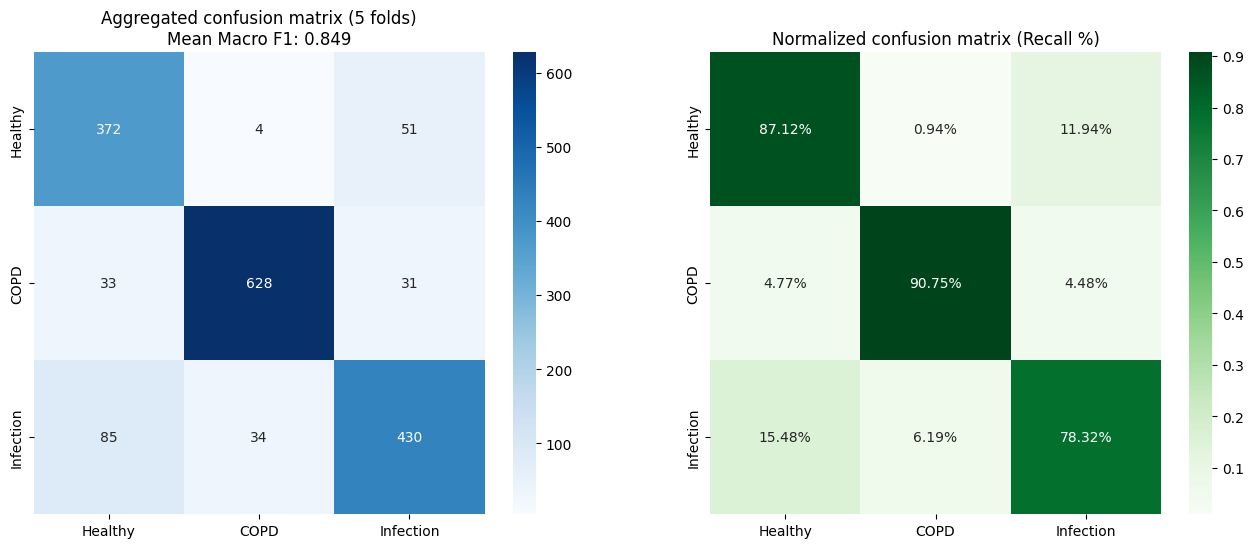

In [40]:
def plot_cv_results(cm, f1_list):
    fig, ax = plt.subplots(1, 2, figsize=(16, 6))

    labels = ['Healthy', 'COPD', 'Infection']

    sns.heatmap(
        cm,
        annot=True,
        fmt='d',
        cmap='Blues',
        ax=ax[0],
        xticklabels=labels,
        yticklabels=labels,
    )
    ax[0].set_title(f'Aggregated confusion matrix (5 folds)\nMean Macro F1: {np.mean(f1_list):.3f}')

    row_sums = cm.sum(axis=1, keepdims=True)
    cm_perc = np.divide(cm.astype(float), row_sums, out=np.zeros_like(cm, dtype=float), where=row_sums != 0)
    sns.heatmap(
        cm_perc,
        annot=True,
        fmt='.2%',
        cmap='Greens',
        ax=ax[1],
        xticklabels=labels,
        yticklabels=labels,
    )
    ax[1].set_title('Normalized confusion matrix (Recall %)')

    plt.show()

plot_cv_results(total_cm, fold_f1)

## Part 8. Held-Out Test Evaluation

Evaluate the final stacked system on the 20% held-out test split after model training and threshold calibration.

In [41]:
y_test_pred_3 = model_multi_3.predict(X_test_scaled)

print('Held-out test macro-F1:', f1_score(y_test_3class, y_test_pred_3, average='macro'))
print('\nHeld-out test confusion matrix:')
print(confusion_matrix(y_test_3class, y_test_pred_3, labels=[0, 1, 2]))
print('\nHeld-out test classification report:')
print(classification_report(
    y_test_3class,
    y_test_pred_3,
    labels=[0, 1, 2],
    target_names=ordered_labels_3,
    zero_division=0,
))

Held-out test macro-F1: 0.8634336574764493

Held-out test confusion matrix:
[[ 23   2   7]
 [  0 164   9]
 [  1   7  55]]

Held-out test classification report:
              precision    recall  f1-score   support

     Healthy       0.96      0.72      0.82        32
        COPD       0.95      0.95      0.95       173
   Infection       0.77      0.87      0.82        63

    accuracy                           0.90       268
   macro avg       0.89      0.85      0.86       268
weighted avg       0.91      0.90      0.90       268



## Part 9. Optuna Hyperparameter Tuning

Tuning the stacking model's base estimators and the meta-learner using Optuna.

In [34]:
import optuna
from sklearn.model_selection import cross_val_score, StratifiedKFold
import optuna.visualization as vis


def objective(trial):
    # 1. Base Models Hyperparameters
    xgb_params = {
        'n_estimators': trial.suggest_int('xgb_n_estimators', 100, 400),
        'max_depth': trial.suggest_int('xgb_max_depth', 3, 8),
        'learning_rate': trial.suggest_float('xgb_lr', 1e-3, 0.1, log=True),
    }

    lgbm_params = {
        'n_estimators': trial.suggest_int('lgbm_n_estimators', 100, 400),
        'learning_rate': trial.suggest_float('lgbm_lr', 1e-3, 0.1, log=True),
        'verbose': -1
    }

    et_params = {
        'n_estimators': trial.suggest_int('et_n_estimators', 100, 400),
        'max_depth': trial.suggest_int('et_max_depth', 5, 20),
        'class_weight': 'balanced'
    }

    rf_params = {
        'n_estimators': trial.suggest_int('rf_n_estimators', 100, 400),
        'max_depth': trial.suggest_int('rf_max_depth', 5, 20),
        'class_weight': 'balanced'
    }

    svc_params = {
        'C': trial.suggest_float('svc_C', 0.1, 10.0, log=True),
        'probability': True,
        'class_weight': 'balanced'
    }

    cat_params = {
        'iterations': trial.suggest_int('cat_iterations', 100, 400),
        'depth': trial.suggest_int('cat_depth', 3, 8),
        'learning_rate': trial.suggest_float('cat_lr', 1e-3, 0.1, log=True),
        'silent': True
    }

    # 2. Meta-Learner Hyperparameters
    meta_params = {
        'n_estimators': trial.suggest_int('meta_n_estimators', 50, 250),
        'max_depth': trial.suggest_int('meta_max_depth', 2, 7),
        'class_weight': 'balanced'
    }

    level0_tuned = [
        ('xgb', xgb.XGBClassifier(**xgb_params, random_state=42)),
        ('lgbm', lgb.LGBMClassifier(**lgbm_params, random_state=42)),
        ('et', ExtraTreesClassifier(**et_params, random_state=42)),
        ('rf', RandomForestClassifier(**rf_params, random_state=42)),
        ('svc', SVC(**svc_params, random_state=42)),
        ('cat', CatBoostClassifier(**cat_params, random_state=42))
    ]

    meta_learner_tuned = RandomForestClassifier(**meta_params, random_state=42)

    stack = StackingClassifier(
        estimators=level0_tuned,
        final_estimator=meta_learner_tuned,
        cv=3, # Reduced inner CV for faster tuning
        stack_method='predict_proba',
        n_jobs=-1
    )

    # Evaluate using 3-Fold CV on training data
    skf_opt = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
    scores = cross_val_score(stack, X_train_scaled, y_train_3class, cv=skf_opt, scoring='f1_macro', n_jobs=1)

    return scores.mean()

print('Starting Optuna Tuning (100 trials or 3600 seconds)...')
study_name = 'stacking_tuning'
storage_name = 'sqlite:///optuna_study.db'
study = optuna.create_study(study_name=study_name, storage=storage_name, direction='maximize', load_if_exists=True)
study.optimize(objective, n_trials=100, timeout=3600)

print('\nBest trial:')
trial = study.best_trial
print(f'  Macro-F1 Score: {trial.value:.4f}')
print('  Best Parameters: ')
for key, value in trial.params.items():
    print(f'    {key}: {value}')


vis.plot_optimization_history(study)
vis.plot_param_importances(study)

[I 2026-04-17 23:08:32,835] Using an existing study with name 'stacking_tuning' instead of creating a new one.


Starting Optuna Tuning (100 trials or 3600 seconds)...


[W 2026-04-17 23:08:39,363] Trial 300 failed with parameters: {'xgb_n_estimators': 143, 'xgb_max_depth': 3, 'xgb_lr': 0.003443619052610061, 'lgbm_n_estimators': 348, 'lgbm_lr': 0.05216086993275863, 'et_n_estimators': 245, 'et_max_depth': 7, 'rf_n_estimators': 343, 'rf_max_depth': 13, 'svc_C': 0.28770989051183643, 'cat_iterations': 234, 'cat_depth': 3, 'cat_lr': 0.001631875809161602, 'meta_n_estimators': 172, 'meta_max_depth': 7} because of the following error: KeyboardInterrupt().
Traceback (most recent call last):
  File "/usr/local/lib/python3.12/dist-packages/optuna/study/_optimize.py", line 206, in _run_trial
    value_or_values = func(trial)
                      ^^^^^^^^^^^
  File "/tmp/ipykernel_129099/4099800937.py", line 73, in objective
    scores = cross_val_score(stack, X_train_scaled, y_train_3class, cv=skf_opt, scoring='f1_macro', n_jobs=1)
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "/usr/local/lib/

KeyboardInterrupt: 